# Lab 3

## Introduction

**What is the goal of this lab?**

In this lab you will practice running statistical tests to determine if a numeric variable has a statistically significant mean for different groups. In other words, does a categorical variable have any potential effect on the numeric variables?

**Context**

Statistical tests are an important first step before building any machine learning model. They help you better undestand the relationships between the variables that could be learned by a machine learning (ML) model. The better you understand these relationships in a data set, the more accurate of a ML model you can create.



### Data

This lab uses the Wine data set 🍷. It contains various measurements of wine made from 3 different categories of grapes grown in the [Piedmont](https://maps.app.goo.gl/mY1kGw27wTFmb4Sw6) region of Italy:
- [Barolo](https://en.wikipedia.org/wiki/Barolo)
- [Grignolino](https://en.wikipedia.org/wiki/Grignolino)
- [Barbera](https://en.wikipedia.org/wiki/Barbera)

You can see more information in the original research paper for the data set [Multivariate data analysis as a discriminating method of the
origin of wines](https://core.ac.uk/download/pdf/235693033.pdf).

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
wine = fetch_ucirepo(name="Wine")

In [ ]:
# Get raw data in a pandas.DataFrame format
wine_df = wine.data.original

In [ ]:
# Citation
print("Citation:\n", wine.metadata.additional_info.citation)

Citation:
 None


> _Aeberhard,Stefan and Forina,M. (1991). Wine._    
> _UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J._


In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(wine.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/109/wine


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:

wine_df.head()
wine_df.shape
wine_df.dtypes
wine_df.isnull()
wine_df.describe()


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


### Data cleaning

The `"class"` column of `wine_df` is currently a numeric index that represents 3 different categories of grapes. In the `"class"` column, replace 1 with *'Barolo'*, 2 with *'Grigonlino'*, and 3 with *'Barbera'*.

```python
{
    1: 'Barolo',
    2: 'Grignolino',
    3: 'Barbera'
}
```
---
**Hints**

- [`pandas.Series.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.replace.html)

In [ ]:

wine_df['class'] = wine_df['class'].replace({
     1: 'Barolo',
     2: 'Grignolino',
     3: 'Barbera'
    })


One of the column names `class` is a keyword in Python and causes problems in the statsmodels package functions. Also the column name `0D280_0D315_of_diluted_wines` is long and confusing. Rename these columns from _'class'_ to _'Grape'_ and _'0D280\_0D315\_of\_diluted_wines'_ to _'Optical\_density'_.

```python
{
    'class': 'Grape',
    '0D280_0D315_of_diluted_wines': 'Optical_density'
}
```
---
**Hints**
- [`pandas.DataFrame.rename()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)

In [ ]:
wine_df = wine.data.original
wine_df = wine_df.rename(columns=
    {'class': 'Grape',
    '0D280_0D315_of_diluted_wines': 'Optical_density'
    })

### Data Visualization and Statistics

Count the number of observations (rows) of each type of grape.

---
**Hints**
- [`pandas.DataFrame.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
- [`pandas.DataFrame.count()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.count.html)

In [ ]:
wine_df.groupby('Grape').size()

,0
Grape,
Barbera,48
Barolo,59
Grignolino,71


Plot the distribution of each variable for each type of grape, and a scatter plot between each pair of numeric variables.

This is a lot of graphs! But it can be easily done with one line of code from the seaborn package.

---
**Hints**
- [`seaborn.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
    - Set the argument `hue="Grape"`

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

wine = fetch_ucirepo(name="Wine")
wine_df = wine.data.original

wine_df['class'] = wine_df['class'].replace({
     1: 'Barolo',
     2: 'Grignolino',
     3: 'Barbera'
    })

wine_df = wine_df.rename(columns=
    {'class': 'Grape',
    '0D280_0D315_of_diluted_wines': 'Optical_density'
    })

sns.pairplot(wine_df, hue='Grape', diag_kind="hist")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Create a [correlation matrix](https://en.wikipedia.org/wiki/Correlation#Correlation_matrices) [heatmap](https://en.wikipedia.org/wiki/Heat_map) for all the numeric variables.

First, drop the `"grape"` column to only have the numeric columns Then create a correlation matrix, where each row and column of the matrix represents a numeric column from the data, and the values in the matrix are the correlations between row-variable and column-variable.

Second, plot the correlation matrix in a heat map to better visualize the correlations:
- Run `plt.figure(figsize=(12, 10))` to increase the size of the graph to make it more readable.
- In the `sns.heatmap()` function set `annot=True` to include the numeric labels in the heat maps and `cmap="coolwarm"` to change the color mapping.

---
**Hints**

- [`pandas.DataFrame.drop()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)
- [`pandas.DataFrame.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
- [`seaborn.heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

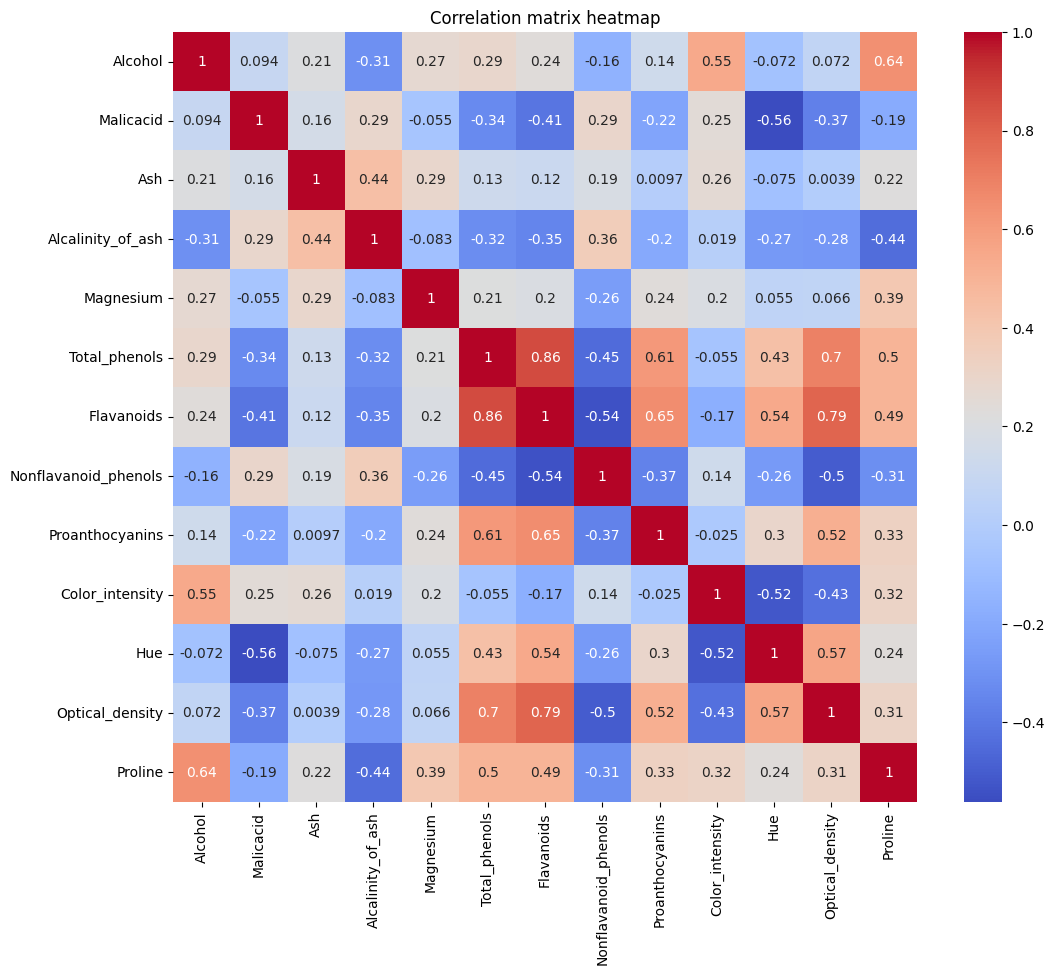

In [ ]:

wine = fetch_ucirepo(name="Wine")
wine_df = wine.data.original

wine_df = wine_df.rename(columns=
    {'class': 'Grape',
    '0D280_0D315_of_diluted_wines': 'Optical_density'
    })

###
numeric_var = wine_df.drop(columns=['Grape'])
corr_matrix = numeric_var.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True,cmap="coolwarm")
plt.title("Correlation matrix heatmap")
plt.show()

## Models

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#### ANOVA

Use the [`statsmodels`](https://www.statsmodels.org/stable/index.html) package to run ANVOA with the `"Grape"` categorical variable against every other variable in the data set. For each variable, print out the F-statistic, p-value, and if the relationship is significant at a level of 0.01.

---
**Hints**
- [`statsmodles.formula.api.ols()`](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html#statsmodels.formula.api.ols)
- [`statsmodels.api.stats.anova_lm()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html)
- [`statsmodels.stats.multicomp.pairwise_tukeyhsd()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html)

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

numeric_col = []
for col in wine_df.columns:
  if pd.api.types.is_numeric_dtype(wine_df[col]) and col != 'Grape':
    numeric_col.append(col)

for col in numeric_col:
  model = ols(f'{col} ~C(Grape)', data=wine_df).fit()
  anova_test = anova_lm(model)

  #f_value
  F_value = anova_test['F'].iloc[0]

  #p_value
  P_value = anova_test['PR(>F)'].iloc[0]

  if P_value < 0.01:
    significant = "Yes"
  else:
    significant = "No"
  print(f'{col}: F={F_value:.3f}, p={P_value:.3e}, Significant? {significant}')


Alcohol: F=135.078, p=3.320e-36, Significant? Yes
Malicacid: F=36.943, p=4.127e-14, Significant? Yes
Ash: F=13.313, p=4.150e-06, Significant? Yes
Alcalinity_of_ash: F=35.772, p=9.444e-14, Significant? Yes
Magnesium: F=12.430, p=8.963e-06, Significant? Yes
Total_phenols: F=93.733, p=2.138e-28, Significant? Yes
Flavanoids: F=233.926, p=3.599e-50, Significant? Yes
Nonflavanoid_phenols: F=27.575, p=3.888e-11, Significant? Yes
Proanthocyanins: F=30.271, p=5.125e-12, Significant? Yes
Color_intensity: F=120.664, p=1.162e-33, Significant? Yes
Hue: F=101.317, p=5.918e-30, Significant? Yes
Optical_density: F=189.972, p=1.393e-44, Significant? Yes
Proline: F=207.920, p=5.783e-47, Significant? Yes


#### Tukey HSD

For each variable that was significant in the ANOVA analysis, use the [`statsmodels`](https://www.statsmodels.org/stable/index.html) package to run a pairwise Tukey HSD test to determine which categories of different from each other with respect to each numeric variable.

---
**Hints**
- [`statsmodels.stats.multicomp.pairwise_tukeyhsd()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html#statsmodels.stats.multicomp.pairwise_tukeyhsd)

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for col in numeric_col:
  model = ols(f'{col} ~C(Grape)', data=wine_df).fit()
  anova_test = anova_lm(model)


  P_value = anova_test['PR(>F)'].iloc[0]

  if P_value < 0.01:
    tukey_test = pairwise_tukeyhsd(wine_df[col], wine_df['Grape'])
    print(tukey_test)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2   meandiff p-adj  lower   upper  reject
--------------------------------------------------------
Barbera     Barolo    0.591   0.0  0.3558  0.8262   True
Barbera Grignolino   -0.875   0.0 -1.1011 -0.6489   True
 Barolo Grignolino   -1.466   0.0 -1.6792 -1.2528   True
--------------------------------------------------------
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2   meandiff p-adj   lower   upper  reject
---------------------------------------------------------
Barbera     Barolo  -1.3231    0.0 -1.7559 -0.8902   True
Barbera Grignolino  -1.4011    0.0 -1.8172 -0.9849   True
 Barolo Grignolino   -0.078 0.8855 -0.4703  0.3143  False
---------------------------------------------------------
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2   meandiff p-adj   lower   upper  reject
---------------------------------------------------------
Barbera     Barolo   

## Conclusion

**What does the F-statistic and p-value of an ANOVA test represent? How should they be interpreted generally? What does a low p-value (< 0.01) mean in the context of this data?**

The F test provides the ratio of variation between group means. A larger F value suggests group means are significantly different. The P value tells us what's the chance that these differences happened randomly. A p-value < 0.01 means that the differences are significant and cannot be ignored.

**What does the adjusted p-value represent in a Tukey HSD test represent? What does it mean if this value is very low?**

The adjusted p-value helps us avoid getting Type 1 or false positive results as it checks if we are comparing the multiple pairs at once. A very low or close to 0 means there is high chance that the two type being compared are significantly different.


**Write a paragraph interpreting the results of the ANOVA analysis. Based on these results which variables might be useful if we were trying to predict which grape each wine is made from?**

The variables with the low p-value are the most useful for telling which grape each wine is made from. Wine ingredients like alcohol, color intensity and proline show clear differences between Barbera, barolo and Grignolino types. Also variables where the groups look similar they are less useful in helping us predict the grape type wine is made from.

**Do the results from the ANOVA tests match your expecations after reviewing the graphs made in the exploratory data analysis? Explain why or why not.**

After reviewing the graphs, I can say that yes the Anova results match and it is within my expected range. The graphs show gaps between grape groups and Anova also supports this saying they were infact significant.